# EFFECT OF OSCILLATIONS

This notebook explores the effect of oscillating species on the accuracy of a linear approximation. The conclusion is that the effect is minimal.

In [1]:
import matplotlib.pyplot as plt  # type: ignore
import numpy as np  # type: ignore
import os
import pandas as pd  # type: ignore
from timecourse_iterator import TimecourseIterator # type: ignore
from typing import Optional, cast, List, Union

import src.constants as cn
from src.score import Score
from src.system_discovery import SystemDiscovery
from src.piecewise_system_discovery import PiecewiseSystemDiscovery
from src.model import Model
from src.timecourse import Timecourse
from src.system_discovery_changepoint_detector import SystemDiscoveryChangepointDetector

# Initializations

In [2]:
# Non-oscillating species timecourses
path = os.path.join(cn.DATA_DIR, f"find_oscillating_models.csv")
NONOSCILLATION_DF = pd.read_csv(path)
NONOSCILLATION_DF = NONOSCILLATION_DF [NONOSCILLATION_DF[cn.COL_FREQUENCIES] == "[]"]
NONOSCILLATION_DF = NONOSCILLATION_DF [NONOSCILLATION_DF[cn.COL_SPECIES_NAME] != cn.COL_AGGREGATION_TYPE_MODEL]
NONOSCILLATION_DF["key"] = [m + "_" + str(s) for m, s in zip(NONOSCILLATION_DF[cn.COL_SYSTEM_ID], NONOSCILLATION_DF[cn.COL_SPECIES_NAME])]
NONOSCILLATION_DF

,system_id,species_name,frequencies,endtime,key
17,BIOMD0000000042,GLC,[],300.0,BIOMD0000000042_GLC
19,BIOMD0000000042,FBP,[],300.0,BIOMD0000000042_FBP
20,BIOMD0000000042,GAP,[],300.0,BIOMD0000000042_GAP
21,BIOMD0000000042,NAD,[],300.0,BIOMD0000000042_NAD
22,BIOMD0000000042,NADH,[],300.0,BIOMD0000000042_NADH
...,...,...,...,...,...
4557,BIOMD0000001059,sursmac,[],7000.0,BIOMD0000001059_sursmac
4558,BIOMD0000001059,smacmit,[],7000.0,BIOMD0000001059_smacmit
4559,BIOMD0000001059,smac,[],7000.0,BIOMD0000001059_smac
4560,BIOMD0000001060,x1,[],40.0,BIOMD0000001060_x1


# Individual models

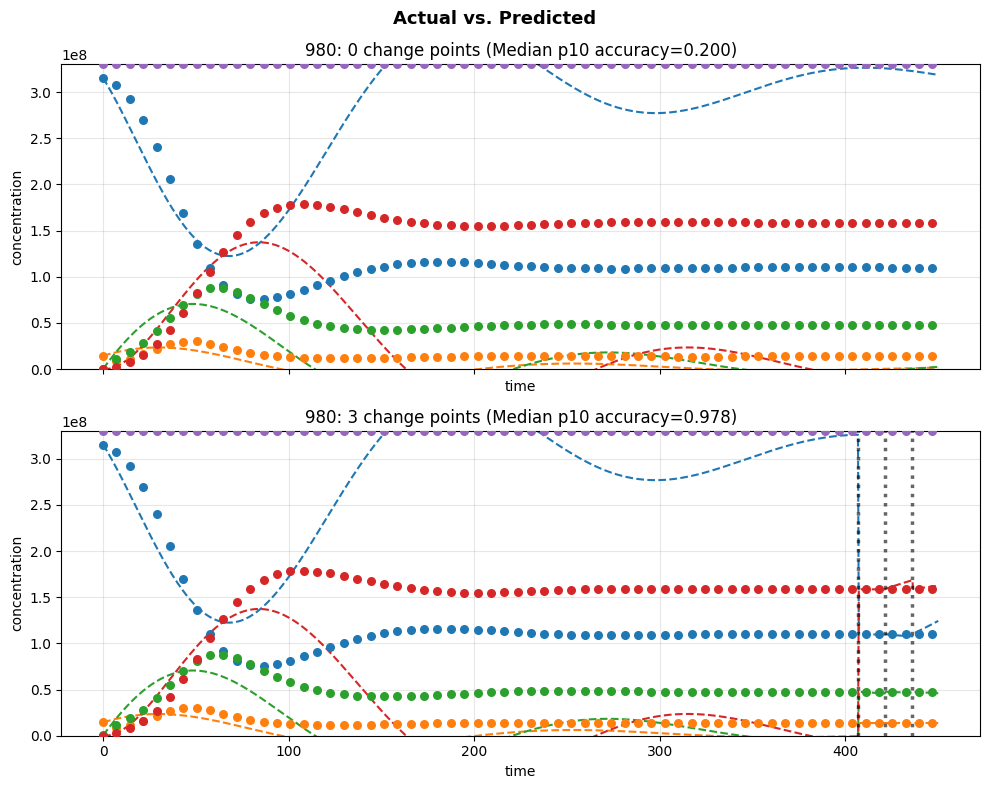

In [13]:
#for model_num in [45, 548, 551, 1045]:
#for model_num in [1045]:
for model_num in [980]:
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, num_point =1000)
    df = timecourse.timecourse_df
    try:
        psd = PiecewiseSystemDiscovery(df, max_changepoint=30, min_segment_length=30,
                                        max_fractional_reduction=0.01, model_name=str(model_num))
        psd.fit()
        result = psd.plotPiecewise(legend=False, num_true_point=60)
    except Exception as e:
        print(f"Could not process {model_num}: {e}")

# CDFs

## All Models

In [4]:
threshold = 0.001
#path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{threshold}.csv")
path = os.path.join(cn.DATA_DIR, f"piecewise_predictions.csv")
DF = pd.read_csv(path)
DF

,system_id,aggregation_type,mean,min,max,count,invalid_count,p05,p10,p20,...,p95,p99,a80,a90,a95,max_changepoint,min_segment_length,max_fractional_reduction,coefficient_threshold,num_changepoint
0,BIOMD0000000005,model,0.000000,0.0,0.000000,6,0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000,0.000,0,50,0.01,0.001,0
1,BIOMD0000000005,C2,0.004453,0.0,0.857498,999,1,0.0,0.0,0.0,...,0.000000,0.000000,0.002002,0.000,0.000,0,50,0.01,0.001,0
2,BIOMD0000000005,CP,0.006316,0.0,1.000000,1000,0,0.0,0.0,0.0,...,0.000000,0.000000,0.005000,0.004,0.003,0,50,0.01,0.001,0
3,BIOMD0000000005,M,0.000000,0.0,0.000000,999,1,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000,0.000,0,50,0.01,0.001,0
4,BIOMD0000000005,pM,0.002001,0.0,1.000000,1000,0,0.0,0.0,0.0,...,0.000000,0.000000,0.002000,0.001,0.001,0,50,0.01,0.001,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30588,BIOMD0000001044,Mass,0.576551,0.0,1.000000,1000,0,0.0,0.0,0.0,...,0.999986,0.999997,0.486000,0.355,0.251,5,50,0.01,0.001,3
30589,BIOMD0000001044,pB,0.130083,0.0,1.000000,1000,0,0.0,0.0,0.0,...,0.870966,0.980482,0.067000,0.043,0.026,5,50,0.01,0.001,3
30590,BIOMD0000001044,pBCKI,NaN,NaN,NaN,0,1000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5,50,0.01,0.001,3
30591,BIOMD0000001044,TriA,0.297397,0.0,1.000000,1000,0,0.0,0.0,0.0,...,0.967082,0.994895,0.242000,0.160,0.066,5,50,0.01,0.001,3


In [5]:
def getColumn(df: pd.DataFrame, col: str = "a80",  is_species: bool = True, max_changepoint: int = 10,
        is_oscillation: bool = True) -> pd.Series:
    if is_species:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] != cn.COL_AGGREGATION_TYPE_MODEL]
    else:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] == cn.COL_AGGREGATION_TYPE_MODEL]
    result_df = result_df[result_df[cn.COL_MAX_CHANGEPOINT] == max_changepoint]
    # Handle oscillations
    if not is_oscillation:
        pass
        
    return result_df[col]

# Tests
ser = getColumn(DF)
ser

22       0.620621
23       0.464000
24       0.224224
25       0.436000
26       0.467467
           ...   
30464    1.000000
30465    0.017751
30521    0.716981
30522    0.713000
30523         NaN
Name: a80, Length: 2954, dtype: float64

In [6]:
def plotCDF(coefficient_threshold: float = 0.001, max_changepoints=[0, 1, 5, 10, 15, 19], is_species: bool = True, col="p10",
        is_non_oscillating: Optional[bool] = None):
    # Construct the dataframe to process
    path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{coefficient_threshold}.csv")
    #path = os.path.join(cn.DATA_DIR, f"piecewise_predictions.csv")
    df = pd.read_csv(path)
    df["key"] = NONOSCILLATION_DF[cn.COL_SYSTEM_ID] + "_" + NONOSCILLATION_DF[cn.COL_SPECIES_NAME]
    if is_non_oscillating is not None:
        df["key"] = NONOSCILLATION_DF[cn.COL_SYSTEM_ID] + "_" + NONOSCILLATION_DF[cn.COL_SPECIES_NAME]
        #
        sel = df["key"].isin(NONOSCILLATION_DF["key"].unique())
        if is_non_oscillating:
            df = df[sel]
        else:
            df = df[~sel]
    #
    dct = {c: getColumn(df, col=col, max_changepoint = c, is_species=is_species) for c in max_changepoints}
    for key, value in dct.items():
        Score.plotCDFArray(value)
    ax = plt.gca()
    ax.legend([str(c) for c in max_changepoints])
    ax.set_xlabel(col + " accuracy")
    qualifier1 = "species" if is_species else "models"
    species_length = len(df["key"].unique())
    model_length = len(df[cn.COL_SYSTEM_ID].unique())
    if is_species:
        length = species_length - model_length
    else:
        length = model_length
    if is_non_oscillating is None:
        qualifier2 = "all"
    else:
        qualifier2 = "non-oscillating" if is_non_oscillating else "oscillating"
    ax.set_title(f"{qualifier2} ({length}) {qualifier1} CDF ({coefficient_threshold})")

In [7]:
df = DF
len(df[cn.COL_SYSTEM_ID].unique())

259

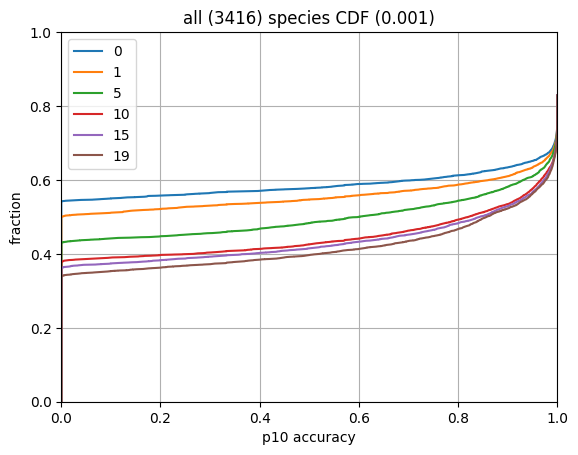

In [8]:
plotCDF(coefficient_threshold=0.001, is_species=True)

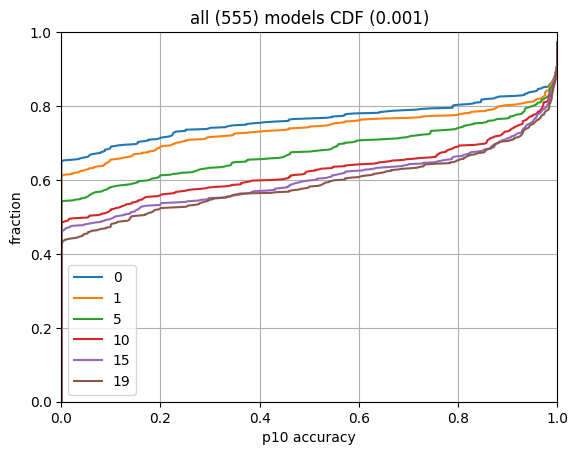

In [9]:
plotCDF(coefficient_threshold=0.001, is_species=False)

**Observations**
1. Increasing the number of changepoints increases accuracy up to about 20 changepoints.
2. There is decreasing benefit of increasing the number of changepoints. For example, going from 0 to 1 changepoint, increases the fraction of p10 = 0.8  by 5%, but there is almost no increase the this fraction by increasing from 10 changepoints to 20 changepoints.
3. About 40% of the species trajectories have a p10 accuracy of 0 even if changepoints are considered.
4. The benefit of increasing changepoints diminishes with the p10 accuracy.
5. For 10 changepoints, approximately 50% of species have a p10 accuracy of 0.8 and 45% a p10 accuracy of 0.9.

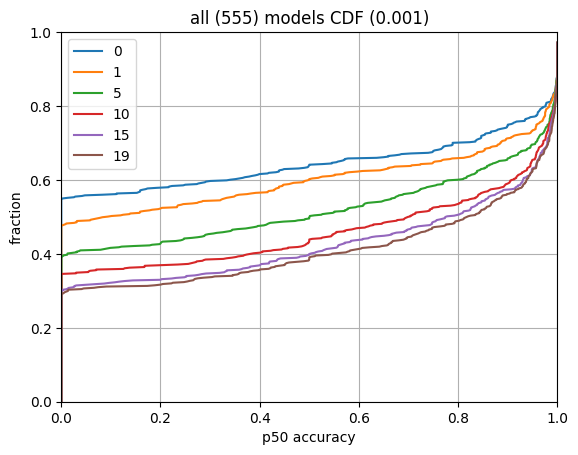

In [10]:
plotCDF(is_species = False, col="p50")

**Observations**
1. For 10 changepoints, approximately, 35% of models have a p10 accuracy of 0.8, and 30% of the models have a p10 accuracy of 0.9.
2. Accuracies for models are generally lower than those for species since a model combines many species and we are considering the tail of the distribution.
3. The other observations about species apply to models.

In [11]:
len(DF["system_id"].unique())

259

## Oscillating vs. Non-Oscillating Models

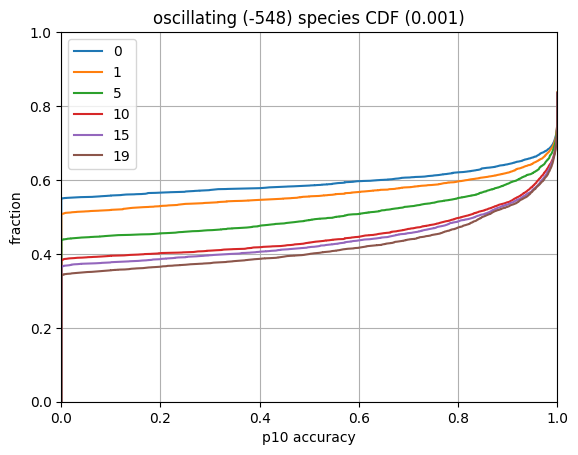

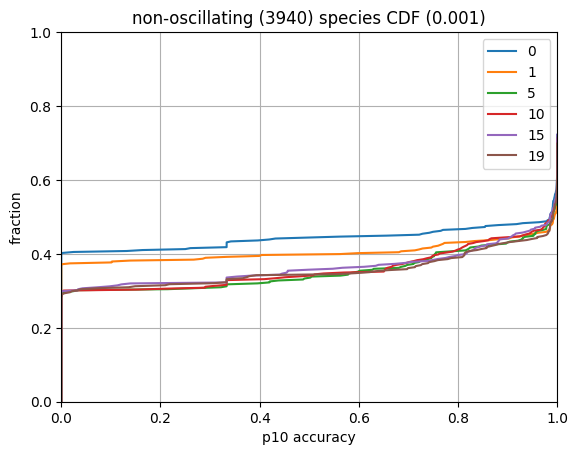

In [12]:
plotCDF(coefficient_threshold=0.001, is_species=True, is_non_oscillating=False)
plt.figure()
plotCDF(coefficient_threshold=0.001, is_species=True, is_non_oscillating=True)